# Power System Operations Workshop: answer sheet

> ⚠️ **This is the answer sheet.** Want to do the workshop yourself? Open [power-system-operations-workshop.ipynb](./power-system-operations-workshop.ipynb) instead.

This notebook was created for the workshop **Powering the Energy Transition: Different Pieces, One Shared Puzzle** on 2026-10-08 at the Bright Cubes office.

It is the **answer sheet** of the workshop assignment: every exercise is followed by a worked-out solution and a short explanation of the result.
The main assignment should take about 45 minutes; the bonus questions at the end are optional.

## Premise

Bright Cubes' LinkedIn post about the NVIDIA DGX Spark attracted a lot of attention, and some customers would like to host their tooling on Bright Cubes servers.
With that in mind, Bright Cubes wants to buy 10 NVIDIA DGX Station GB300 machines, each with a peak total system power of 1600 W.
Their current connection does not have enough capacity for that, so they request an increase of their allocated capacity by 10 × 1600 W = 16 kW.

### Your role

You are a power system operator with one goal: bringing the energy transition to a good end without blackouts.
You need to answer the following questions:

* Can we increase the capacity for Bright Cubes?
* If not, can we offer a compromise?

A customer request can only be approved safely if the following constraints remain satisfied:

1. **Time series analysis:** given a forecast (simulation) of production and consumption, no cable or transformer may exceed its rated capacity at any moment.
2. **N-1 analysis:** if any single cable breaks or is disconnected for maintenance, there is always an alternative grid configuration that can run the entire time series without exceeding equipment capacities.

### Tools

* [Power Grid Model (PGM)](https://power-grid-model.readthedocs.io/): fast power flow calculations, including batch (time series) calculations.
* [Power Grid Model Data Science (PGM-DS)](https://power-grid-model-ds.readthedocs.io/): grid objects with graph functionality and an interactive visualizer.

## Set-up

Import the libraries and define the constants used throughout the notebook.


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import power_grid_model as pgm
import power_grid_model_ds as pgm_ds
import power_grid_model_ds.visualizer as pgm_viz
from power_grid_model.data_types import Dataset
from power_grid_model.typing import ComponentAttributeMapping
from power_grid_model.utils import json_deserialize_from_file
from power_grid_model.validation import (
    errors_to_string,
    validate_batch_data,
    validate_input_data,
)

# Loading = actual current (or power) / rated current (or power); 1.0 means 100%
MAX_LOADING = 1.0

# Cables (lines) and transformers are the equipment that can get overloaded
BRANCHES = (pgm.ComponentType.line, pgm.ComponentType.transformer)

## Grid dataset

The example network is stored in `data/workshop_grid.json` (a fictional grid; no real-world data was used). It contains:

| Component | IDs | Description |
| --- | --- | --- |
| `node` | 1 – 23 | 150 kV source bus (1), 10.5 kV medium-voltage ring (2 – 17), 400 V low-voltage feeders (18 – 23) |
| `line` (cable) | 1001 – 1021 | medium-voltage ring cables (1001 – 1016) and low-voltage cables (1017 – 1021) |
| `transformer` | 2001 – 2006 | 150/10.5 kV transformers (2001, 2002) and 10.5/0.4 kV transformers (2003 – 2006) |
| `source` | 3001 | connection to the high-voltage grid |
| `sym_load` | 4001 – 4010 | customers; Bright Cubes is load `4010` |
| `sym_gen` | 5001 – 5005 | rooftop solar installations |

Distribution grids are usually built as loops (meshes) but **operated radially**: some cables and transformers are switched off (`from_status = to_status = 0`).
These *normally open points* (lines 1006, 1013, 1018, 1019 and transformer 2006) can be switched on as a back-up when something breaks, which is exactly what the N-1 analysis is about.

Load the data and convert it to a PGM-DS `Grid` object.

In [2]:
input_data = json_deserialize_from_file(Path("data/workshop_grid.json"))

# PGM-DS turns the raw input data into a Grid object with graph functionality
interface = pgm_ds.PowerGridModelInterface(input_data=input_data)
grid = interface.create_grid_from_input_data()
grid.check_ids()

print(
    f"Loaded {len(grid.node)} nodes, {len(grid.line)} lines, "
    f"{len(grid.transformer)} transformers, {len(grid.source)} source, "
    f"{len(grid.sym_load)} loads and {len(grid.sym_gen)} solar generators."
)

Loaded 23 nodes, 21 lines, 6 transformers, 1 source, 10 loads and 5 solar generators.


### Visualize the network

Use the PGM-DS visualizer to inspect the grid.

Things to look for: where is the source, where is Bright Cubes (load `4010` at node `23`), and which cables and transformers are switched off (normally open points)?

> Tip: the visualizer runs a small web server on port 8050. If running the cell again gives `Address 'http://127.0.0.1:8050' already in use`, restart the kernel first, or pass another port, e.g. `pgm_viz.visualize(grid, port=8051)`.

In [3]:
pgm_viz.visualize(grid)

### Validate data sanity

Run the PGM data validator to check that all required attributes are set and have valid values.
Always validate before calculating: invalid data either raises a cryptic error or, worse, gives wrong results silently.

In [4]:
validation_errors = validate_input_data(
    input_data, calculation_type=pgm.CalculationType.power_flow, symmetric=True
)
if validation_errors:
    raise ValueError(errors_to_string(validation_errors, "input_data", details=True))

print("Input data is valid for a symmetric power flow calculation.")

Input data is valid for a symmetric power flow calculation.


### Validate the base scenario

Run a single power flow calculation on the input data and check whether any cable or transformer is overloaded.

PGM reports the `loading` of every branch:

* cable: highest current at either end / rated current `i_n`
* transformer: highest apparent power at either side / rated power `sn`

A loading above `MAX_LOADING` (100%) means the equipment is overloaded.

In [5]:
def check_loadings(output_data: Dataset) -> bool:
    """Print the peak loading per equipment type; return True if nothing is overloaded.

    Works for a single calculation and for a batch (time series) calculation.
    """
    within_limits = True
    for component in BRANCHES:
        # Shape (time steps, equipment); a single calculation counts as one time step
        loading = np.atleast_2d(output_data[component]["loading"])
        ids = np.atleast_2d(output_data[component]["id"])[0]

        peak_per_equipment = loading.max(axis=0)
        overloaded_ids = ids[peak_per_equipment > MAX_LOADING]
        within_limits &= overloaded_ids.size == 0

        print(
            f"{component.value}: max loading {peak_per_equipment.max():.1%} "
            f"(id {ids[peak_per_equipment.argmax()]}), "
            f"overloaded ids: {overloaded_ids.tolist() or 'none'}"
        )
    return within_limits


model = pgm.PowerGridModel(input_data)
output_data = model.calculate_power_flow(symmetric=True)
base_scenario_ok = check_loadings(output_data)

line: max loading 95.5% (id 1021), overloaded ids: none
transformer: max loading 87.3% (id 2005), overloaded ids: none


**Answer:** nothing is overloaded in the base scenario.
Cable 1021 (95.5%), which feeds Bright Cubes, and transformer 2005 (87.3%) are the most heavily loaded, so watch them in the next steps.

But a single snapshot says little: consumption and solar production change throughout the day and the year.

### Simulate the current state

`data/workshop_timeseries.json` contains a forecast of one year of consumption (`sym_load`) and solar production (`sym_gen`) at a 6-hourly resolution.
Every time step (*scenario*) updates the `p_specified` and `q_specified` of every load and generator.

Validate the update data, run a **batch** power flow over all time steps and check that nothing is overloaded at any moment.

In [6]:
update_data = json_deserialize_from_file(Path("data/workshop_timeseries.json"))

batch_errors = validate_batch_data(
    input_data,
    update_data,
    calculation_type=pgm.CalculationType.power_flow,
    symmetric=True,
)
if batch_errors:
    raise ValueError(errors_to_string(batch_errors, "update_data", details=True))

# Update arrays have shape (time steps, components)
n_steps = update_data[pgm.ComponentType.sym_load].shape[0]
print(f"Running {n_steps} time steps.")

# One batch calculation runs all time steps at once; threading=0 uses all CPU cores
batch_output = model.calculate_power_flow(
    update_data=update_data, symmetric=True, threading=0
)
current_state_ok = check_loadings(batch_output)

Running 1460 time steps.
line: max loading 96.9% (id 1021), overloaded ids: none
transformer: max loading 91.1% (id 2005), overloaded ids: none


**Answer:** the grid is fine today: the highest loadings over the whole year are 96.9% (cable 1021) and 91.1% (transformer 2005).

Plot the loading of the cables and transformers over time to see *when* they are highest.
A year of 6-hourly values in one line is unreadable because of the daily cycle, so the plot shows one panel per time of day.
Equipment that gets close to its limit is highlighted; the rest is grey.

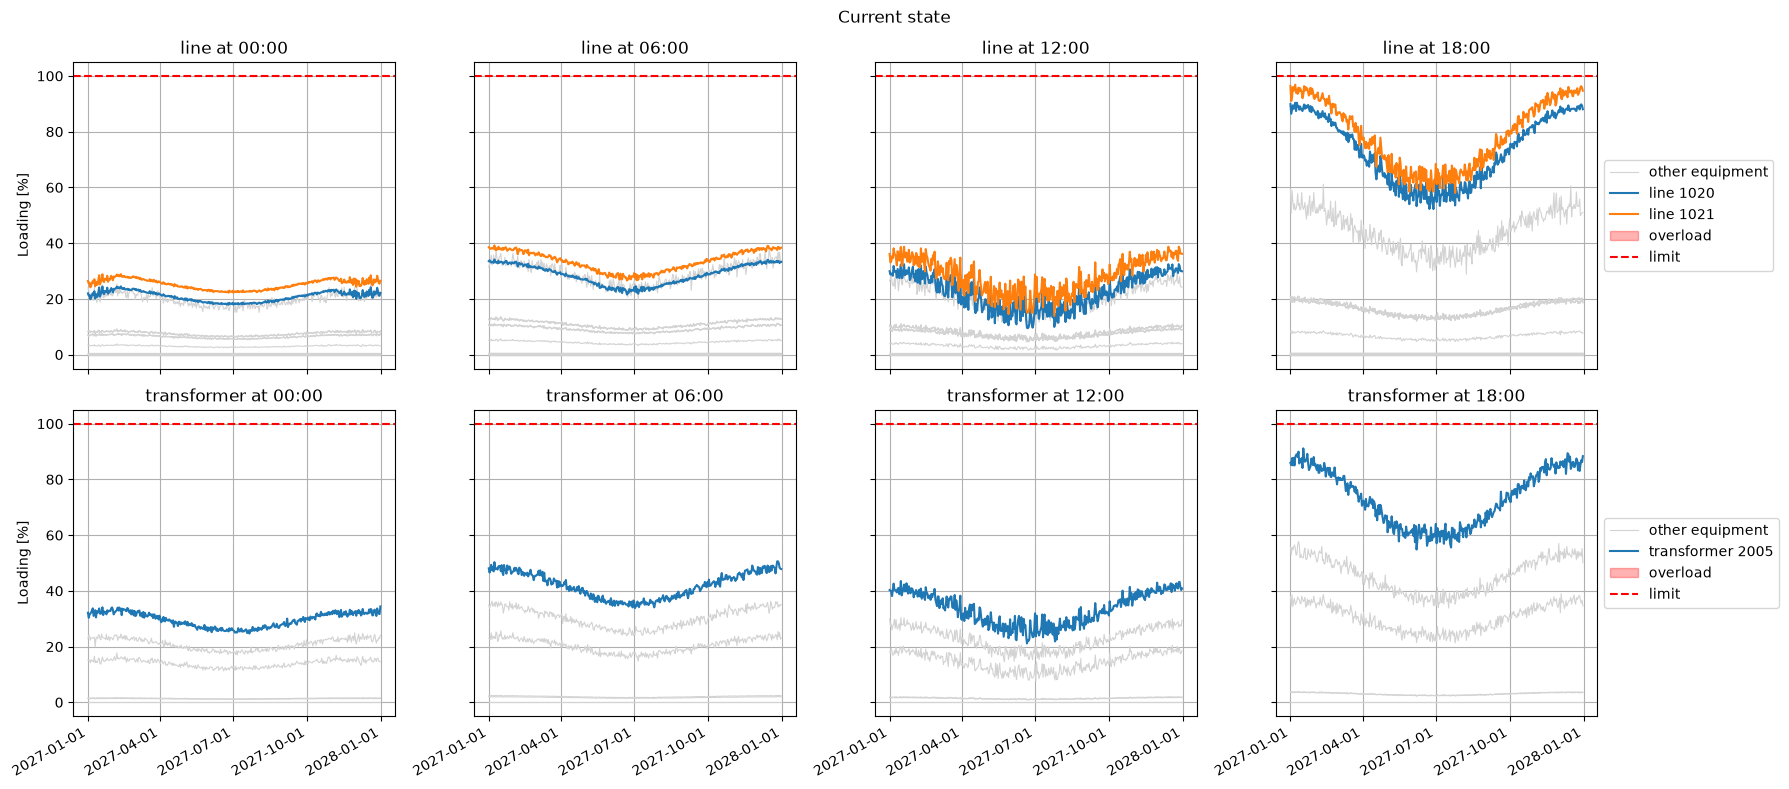

In [7]:
HOURS_PER_STEP = 6
STEPS_PER_DAY = 24 // HOURS_PER_STEP
WATCH_LOADING = 0.9  # equipment above this loading gets a colour in the plot

# The forecast covers the year 2027
time_step = np.timedelta64(HOURS_PER_STEP, "h")
timestamps = np.datetime64("2027-01-01T00:00") + np.arange(n_steps) * time_step
days = timestamps[::STEPS_PER_DAY]


def plot_loadings(batch_output: Dataset, title: str) -> None:
    """Plot the loading of every cable and transformer, one panel per time of day."""
    fig, axes = plt.subplots(
        len(BRANCHES), STEPS_PER_DAY, figsize=(18, 8), sharex=True, sharey="row"
    )
    for row, component in enumerate(BRANCHES):
        # (time steps, equipment) -> (days, time of day, equipment), in percent
        loading = 100 * batch_output[component]["loading"].reshape(
            len(days), STEPS_PER_DAY, -1
        )
        ids = batch_output[component]["id"][0]
        watched = np.flatnonzero(loading.max(axis=(0, 1)) >= 100 * WATCH_LOADING)
        others = np.setdiff1d(np.arange(len(ids)), watched)

        for col, ax in enumerate(axes[row]):
            other_lines = ax.plot(
                days, loading[:, col, others], color="lightgrey", linewidth=0.8
            )
            other_lines[0].set_label("other equipment")
            for color_idx, idx in enumerate(watched):
                ax.plot(
                    days,
                    loading[:, col, idx],
                    color=f"C{color_idx}",
                    linewidth=1.5,
                    label=f"{component.value} {ids[idx]}",
                )
            ax.fill_between(
                days,
                0,
                1,
                where=(loading[:, col] > 100 * MAX_LOADING).any(axis=1),
                color="red",
                alpha=0.3,
                transform=ax.get_xaxis_transform(),
                label="overload",
            )
            ax.axhline(100 * MAX_LOADING, color="red", linestyle="--", label="limit")
            ax.set_title(f"{component.value} at {col * HOURS_PER_STEP:02d}:00")
            ax.grid(True)
            ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

        axes[row, 0].set_ylabel("Loading [%]")
        axes[row, -1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

    fig.suptitle(title)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


plot_loadings(batch_output, "Current state")

**Explanation:** the loading peaks at **18:00 in winter**: everyone is home cooking and heating, while the sun is down so the rooftop solar panels produce nothing.
At midday, solar production compensates part of the consumption, which is why the 12:00 panels show the lowest loading in summer.
The bottleneck is cable 1021, the cable that feeds Bright Cubes.

## Bright Cubes capacity request

The current state of the grid is fine, but that was not the original question.

Bright Cubes (load `4010`) wants to buy 10 NVIDIA DGX Station GB300 machines of 1600 W each: 16 kW extra.
Add this to their consumption in the forecast and check whether the grid can handle it.

As an operator you have to assume the **worst case**: the customer may use its full allocated capacity at any moment, so the extra 16 kW is added to every time step.

line: max loading 101.8% (id 1021), overloaded ids: [1021]
transformer: max loading 92.8% (id 2005), overloaded ids: none


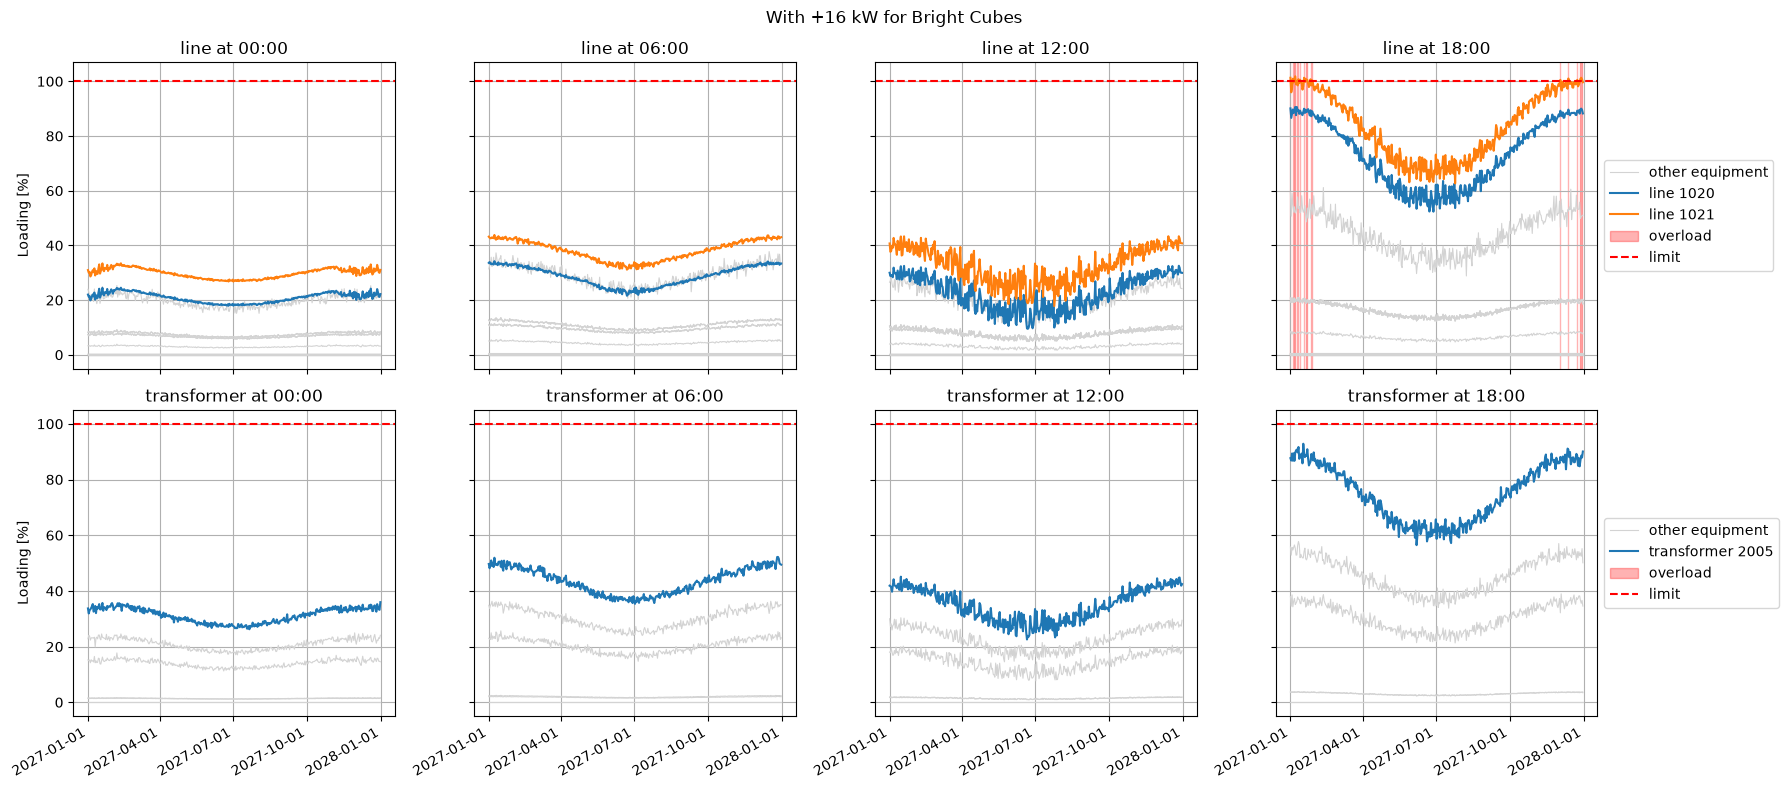

In [8]:
BRIGHT_CUBES_LOAD_ID = 4010
STATION_POWER = 1_600.0  # W, peak power of one NVIDIA DGX Station GB300
REQUESTED_STATIONS = 10
REQUESTED_POWER = REQUESTED_STATIONS * STATION_POWER  # W


def add_bright_cubes_power(
    time_series: Dataset, extra_power: float | npt.NDArray[np.float64]
) -> Dataset:
    """Return a copy of the time series in which Bright Cubes consumes more power.

    `extra_power` [W] is one value for all time steps or one value per time step.
    """
    new_time_series = {name: data.copy() for name, data in time_series.items()}
    loads = new_time_series[pgm.ComponentType.sym_load]
    is_bright_cubes = loads["id"][0] == BRIGHT_CUBES_LOAD_ID
    # As a column, so that a value per time step is added to the matching row
    loads["p_specified"][:, is_bright_cubes] += np.reshape(extra_power, (-1, 1))
    return new_time_series


request_update = add_bright_cubes_power(update_data, REQUESTED_POWER)
request_output = model.calculate_power_flow(
    update_data=request_update, symmetric=True, threading=0
)
request_fits = check_loadings(request_output)
plot_loadings(request_output, f"With +{REQUESTED_POWER / 1000:.0f} kW for Bright Cubes")

**Answer: no, the request does not fit.**
Cable 1021 reaches 101.8% on several winter evenings at 18:00, exactly the moments that were already the busiest.
Transformer 2005 gets busier too (92.8%) but stays within its limit.

### Come up with a compromise

How many NVIDIA DGX Station GB300 machines can Bright Cubes buy instead?

Approach: increase the number of machines one at a time and stop as soon as something gets overloaded.

In [9]:
def peak_loading(grid_model: pgm.PowerGridModel, time_series: Dataset) -> float:
    """Run the time series; return the highest loading of any cable or transformer."""
    output = grid_model.calculate_power_flow(
        update_data=time_series, symmetric=True, threading=0
    )
    return max(float(output[component]["loading"].max()) for component in BRANCHES)


max_stations = 0
for n_stations in range(1, REQUESTED_STATIONS + 1):
    extra_power = n_stations * STATION_POWER
    peak = peak_loading(model, add_bright_cubes_power(update_data, extra_power))
    print(
        f"{n_stations:2d} stations (+{extra_power / 1000:4.1f} kW): "
        f"max loading {peak:.2%}"
    )
    # More consumption only increases the loading, so stop at the first overload
    if peak > MAX_LOADING:
        break
    max_stations = n_stations

print(
    f"\nBright Cubes can buy at most {max_stations} stations "
    f"(+{max_stations * STATION_POWER / 1000:.1f} kW)."
)

 1 stations (+ 1.6 kW): max loading 97.37%
 2 stations (+ 3.2 kW): max loading 97.86%
 3 stations (+ 4.8 kW): max loading 98.36%
 4 stations (+ 6.4 kW): max loading 98.86%
 5 stations (+ 8.0 kW): max loading 99.35%
 6 stations (+ 9.6 kW): max loading 99.85%
 7 stations (+11.2 kW): max loading 100.35%

Bright Cubes can buy at most 6 stations (+9.6 kW).


**Answer:** Bright Cubes can buy **6 machines (+9.6 kW)**; the 7th would overload cable 1021.

Each machine adds roughly 0.5 percentage points to the peak loading of cable 1021, so the 3.1% headroom of the current state is enough for 6 machines.
With 6 machines the peak loading is 99.85%, which leaves no margin for forecast errors at all. In practice, an operator would probably offer a bit less.

## Summary of the main assignment

| Question | Answer |
| --- | --- |
| Is the grid fine today? | Yes, peak loading 96.9% (cable 1021, winter evenings at 18:00) |
| Can Bright Cubes get +16 kW (10 machines)? | No, cable 1021 would reach 101.8% |
| Compromise? | +9.6 kW (6 machines) fits the time series analysis |

## Bonus question 1: alternative solutions

Is there an alternative solution that would still allow Bright Cubes to buy all 10 NVIDIA DGX Station GB300 machines?

**Answer:** yes, for example with a **time-dependent connection (flexible capacity)**.
The overload only happens at 18:00, when Bright Cubes' employees have gone home and their customers likely use less computing power too.
Bright Cubes gets the full +16 kW, except during the evening peak, when it gets a lower limit.

Other options (not worked out): reinforce the grid by replacing cable 1021 with a heavier one (expensive and slow), or let Bright Cubes install a battery that covers the evening peak.

Give Bright Cubes the full +16 kW, except at 18:00. How many machines can run at full power at 18:00?

In [10]:
EVENING_PEAK_HOUR = 18

hour_of_day = np.arange(n_steps) % STEPS_PER_DAY * HOURS_PER_STEP
is_evening_peak = hour_of_day == EVENING_PEAK_HOUR

max_evening_stations = 0
for n_stations in range(1, REQUESTED_STATIONS + 1):
    # Full request outside the evening peak, n_stations at the evening peak
    power_profile = np.where(
        is_evening_peak, n_stations * STATION_POWER, REQUESTED_POWER
    )
    peak = peak_loading(model, add_bright_cubes_power(update_data, power_profile))
    print(f"{n_stations:2d} stations at {EVENING_PEAK_HOUR}:00: max loading {peak:.2%}")
    if peak > MAX_LOADING:
        break
    max_evening_stations = n_stations

print(
    f"\nAll {REQUESTED_STATIONS} stations fit outside the evening peak, "
    f"if at most {max_evening_stations} run at {EVENING_PEAK_HOUR}:00."
)

 1 stations at 18:00: max loading 97.37%
 2 stations at 18:00: max loading 97.86%
 3 stations at 18:00: max loading 98.36%
 4 stations at 18:00: max loading 98.86%
 5 stations at 18:00: max loading 99.35%
 6 stations at 18:00: max loading 99.85%
 7 stations at 18:00: max loading 100.35%

All 10 stations fit outside the evening peak, if at most 6 run at 18:00.


**Answer:** Bright Cubes can use all 10 machines (+16 kW) at 00:00, 06:00 and 12:00, and 6 machines (+9.6 kW) at 18:00.
The evening limit equals the compromise of the main assignment, because 18:00 is the only moment where the grid is the bottleneck.
A further refinement would be to apply the lower limit only in winter, since the overloads only occur in December and January.

## Bonus question 2: N-1 safety (hard)

Power system operators also need to get customers back online as soon as possible when something goes wrong.
A broken cable has to be repaired or replaced, which can take days, weeks or even longer, so a temporary alternative is needed in the meantime.

That alternative is a different routing of the power, using the normally open points.
For example, if cable `1021` between node `21` and node `23` breaks, nodes `22` and `23` lose power. They can be reconnected by:

1. switching on cable `1019` between node `21` and node `22`;
2. switching on transformer `2006` between node `9` and node `22`;
3. switching on both. This is the most likely to work, because it spreads the power over the most equipment.

A rerouting can overload other equipment, in which case it is rejected.
A simple way to check whether a safe alternative exists for every fault is:

1. Switch on all cables and transformers.
2. For every cable:
   1. Switch off that cable (this is the fault).
   2. Run the time series.
   3. If any node is not energized or any equipment is overloaded, the grid is **not safe** under this fault.
3. The grid is **N-1 safe** if it is safe under every possible cable fault.

> Note: switching everything on is a simplification, and an optimistic one: it uses all back-up routes at the same time, while a real grid is operated radially again after a fault.
> In practice, an operator would look for the best radial configuration per fault, which can give a stricter result. That is beyond the scope of this workshop.

Questions:

* Is the original grid (without the request of Bright Cubes) N-1 safe?
* If so, how many NVIDIA DGX Station GB300 machines can Bright Cubes buy while keeping the grid N-1 safe?

### Set up the N-1 analysis

In [11]:
# Step 1: switch on all cables and transformers
n1_input = {component: data.copy() for component, data in input_data.items()}
for component in BRANCHES:
    n1_input[component]["from_status"] = 1
    n1_input[component]["to_status"] = 1
n1_model = pgm.PowerGridModel(n1_input)


def make_fault_model(line_id: int) -> pgm.PowerGridModel:
    """Step 2.1: return a copy of the N-1 model with one cable switched off."""
    fault_model = n1_model.copy()
    fault = pgm.initialize_array(pgm.DatasetType.update, pgm.ComponentType.line, 1)
    fault["id"] = line_id
    fault["from_status"] = 0
    fault["to_status"] = 0
    fault_model.update(update_data={pgm.ComponentType.line: fault})
    return fault_model


# One model per fault, so the topology stays fixed during each batch calculation
fault_models = {
    int(line_id): make_fault_model(int(line_id))
    for line_id in n1_input[pgm.ComponentType.line]["id"]
}

# Only request the results that are needed: saves memory and time
N1_OUTPUT: ComponentAttributeMapping = {
    pgm.ComponentType.node: ["energized"],
    **{component: ["loading"] for component in BRANCHES},
}


def check_fault(
    fault_model: pgm.PowerGridModel, time_series: Dataset
) -> tuple[bool, str, float]:
    """Steps 2.2 and 2.3: run the time series on a grid with one cable fault.

    Return whether the grid is safe, the reason and the peak loading.
    """
    output = fault_model.calculate_power_flow(
        update_data=time_series,
        symmetric=True,
        threading=0,
        output_component_types=N1_OUTPUT,
    )
    peak = max(float(output[component]["loading"].max()) for component in BRANCHES)
    if not output[pgm.ComponentType.node]["energized"].all():
        return False, "not all nodes energized", peak
    if peak > MAX_LOADING:
        return False, "overloaded", peak
    return True, "safe", peak


def find_unsafe_faults(time_series: Dataset) -> list[int]:
    """Step 3: return the cables whose fault makes the grid unsafe (empty: N-1 safe)."""
    return [
        line_id
        for line_id, fault_model in fault_models.items()
        if not check_fault(fault_model, time_series)[0]
    ]

### Is the original grid N-1 safe?

In [12]:
original_n1_safe = True
for line_id, fault_model in fault_models.items():
    safe, reason, peak = check_fault(fault_model, update_data)
    original_n1_safe &= safe
    print(f"fault on cable {line_id}: {reason} (max loading {peak:.1%})")

print(f"\nThe original grid is {'' if original_n1_safe else 'NOT '}N-1 safe.")

fault on cable 1001: safe (max loading 79.4%)
fault on cable 1002: safe (max loading 79.5%)
fault on cable 1003: safe (max loading 79.5%)
fault on cable 1004: safe (max loading 76.9%)
fault on cable 1005: safe (max loading 75.7%)
fault on cable 1006: safe (max loading 75.7%)
fault on cable 1007: safe (max loading 99.2%)
fault on cable 1008: safe (max loading 72.0%)
fault on cable 1009: safe (max loading 72.0%)
fault on cable 1010: safe (max loading 75.9%)
fault on cable 1011: safe (max loading 75.9%)
fault on cable 1012: safe (max loading 75.9%)
fault on cable 1013: safe (max loading 75.9%)
fault on cable 1014: safe (max loading 75.9%)
fault on cable 1015: safe (max loading 75.9%)
fault on cable 1016: safe (max loading 75.9%)
fault on cable 1017: safe (max loading 76.7%)
fault on cable 1018: safe (max loading 75.9%)
fault on cable 1019: safe (max loading 74.4%)
fault on cable 1020: safe (max loading 74.6%)
fault on cable 1021: safe (max loading 76.0%)

The original grid is N-1 safe.


**Answer: yes**, the original grid is N-1 safe, but only just.
A fault on cable 1007 (between node 8 and node 9) pushes the small 400 kVA transformer 2006 to 99.2%:
node 8 is then fed via the long way around the ring, so its voltage drops and more power flows to the low-voltage grid via transformer 2006 instead of transformer 2005.

### How many machines keep the grid N-1 safe?

Repeat the N-1 analysis with an increasing number of machines and stop at the first unsafe fault.

In [13]:
max_n1_stations = 0
for n_stations in range(1, REQUESTED_STATIONS + 1):
    extra_power = n_stations * STATION_POWER
    unsafe_faults = find_unsafe_faults(add_bright_cubes_power(update_data, extra_power))
    print(
        f"{n_stations:2d} stations (+{extra_power / 1000:4.1f} kW): "
        f"unsafe faults: {unsafe_faults or 'none'}"
    )
    if unsafe_faults:
        break
    max_n1_stations = n_stations

print(
    f"\nThe grid stays N-1 safe with at most {max_n1_stations} stations "
    f"(+{max_n1_stations * STATION_POWER / 1000:.1f} kW)."
)

 1 stations (+ 1.6 kW): unsafe faults: none
 2 stations (+ 3.2 kW): unsafe faults: none
 3 stations (+ 4.8 kW): unsafe faults: none
 4 stations (+ 6.4 kW): unsafe faults: none
 5 stations (+ 8.0 kW): unsafe faults: [1007]

The grid stays N-1 safe with at most 4 stations (+6.4 kW).


**Answer:** with N-1 safety, Bright Cubes can buy **4 machines (+6.4 kW)**; with 5 machines, a fault on cable 1007 overloads transformer 2006.

The N-1 constraint is stricter than the time series constraint (6 machines), so it determines the final offer.
Remember that this N-1 method is optimistic: with the radial back-up for a fault on cable 1007 (switching on cable 1006 only), cable 1021 already reaches 99.4% without the request, so a real operator would offer even less.
This is typical: a grid has to be able to cope with a fault at the worst possible moment, not just with normal operation.

## Final summary

| Question | Answer |
| --- | --- |
| Can Bright Cubes get +16 kW (10 machines)? | No: cable 1021 is overloaded on winter evenings |
| Compromise (time series analysis) | 6 machines (+9.6 kW) |
| Compromise (time series and N-1 analysis) | 4 machines (+6.4 kW) |
| Alternatives for all 10 machines | Time-dependent connection (6 machines at 18:00), grid reinforcement or a battery; each must pass both analyses again |